Generando 3 trayectorias acopladas...


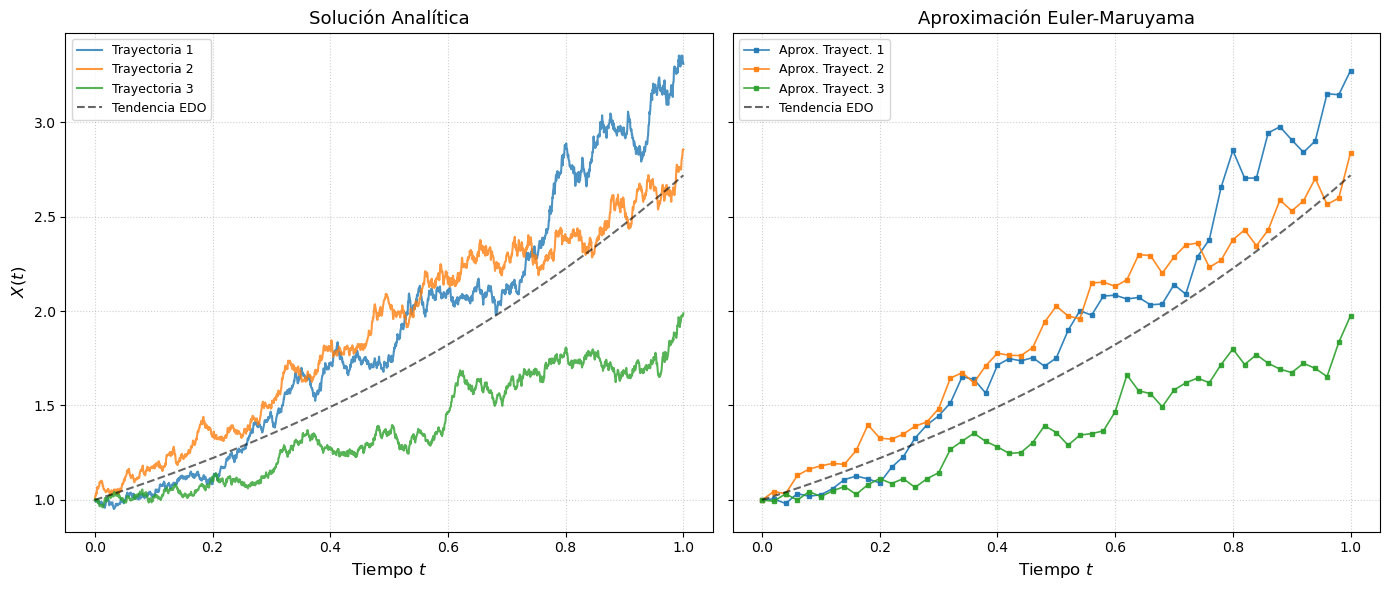

¡Proceso finalizado! Archivo 'ejemplo1_trayectorias_acopladas.pdf' generado.


In [75]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1) CONFIGURACIÓN DE PARÁMETROS Y MALLAS
# =================================================================
X0, mu, sigma, T = 1.0, 1.0, 0.3, 1.0
n_paths = 3       # Número de trayectorias a mostrar
N_exact = 2000    # Resolución cuasi-continua para la "realidad"
N_euler = 50      # Resolución gruesa para ver el error del método numérico

# El factor indica cuántos pasos finos sumamos para hacer un paso grueso
factor = N_exact // N_euler  

t_fine = np.linspace(0, T, N_exact + 1)
t_coarse = np.linspace(0, T, N_euler + 1)
h_euler = T / N_euler

# Colores fijos para identificar las parejas (Exacta <-> Euler)
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Creamos la figura con 2 subgráficas compartiendo el eje Y
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Tendencia determinista (EDO) para referencia
X_det = X0 * np.exp(mu * t_fine)

print(f"Generando {n_paths} trayectorias acopladas...")

# =================================================================
# 2) BUCLE DE GENERACIÓN Y SIMULACIÓN
# =================================================================
for i in range(n_paths):
    # --- GENERACIÓN DEL RUIDO BASE (Malla Fina) ---
    dW_fine = np.sqrt(T/N_exact) * np.random.normal(size=N_exact)
    W_fine = np.zeros(N_exact + 1)
    W_fine[1:] = np.cumsum(dW_fine)
    
    # --- 1. SOLUCIÓN EXACTA (Trayectoria Continua) ---
    X_ex = X0 * np.exp((mu - 0.5 * sigma**2) * t_fine + sigma * W_fine)
    ax1.plot(t_fine, X_ex, color=colores[i], lw=1.5, alpha=0.8, label=f'Trayectoria {i+1}')
    
    # --- 2. SOLUCIÓN EULER-MARUYAMA (Trayectoria Discreta) ---
    # Acoplamiento: sumamos los incrementos finos para el paso grueso
    dW_coarse = dW_fine.reshape(N_euler, factor).sum(axis=1)
    
    X_em = np.zeros(N_euler + 1)
    X_em[0] = X0
    for j in range(N_euler):
        X_em[j+1] = X_em[j] + mu * X_em[j] * h_euler + sigma * X_em[j] * dW_coarse[j]
    
    # Dibujamos con marcadores para resaltar la discretización
    ax2.plot(t_coarse, X_em, color=colores[i], marker='s', markersize=3, 
             lw=1.2, alpha=0.9, label=f'Aprox. Trayect. {i+1}')

# =================================================================
# 3) ESTÉTICA Y GUARDADO
# =================================================================
ax1.plot(t_fine, X_det, 'k--', alpha=0.6, label='Tendencia EDO')
ax2.plot(t_fine, X_det, 'k--', alpha=0.6, label='Tendencia EDO')

ax1.set_title(f'Solución Analítica', fontsize=13)
ax2.set_title(f'Aproximación Euler-Maruyama', fontsize=13)

ax1.set_ylabel('$X(t)$', fontsize=12)
for ax in [ax1, ax2]:
    ax.set_xlabel('Tiempo $t$', fontsize=12)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=9)

plt.tight_layout()

# Guardar para Overleaf
fig.savefig('ejemplo1_trayectorias_acopladas.pdf', bbox_inches='tight')
plt.show()

print("¡Proceso finalizado! Archivo 'ejemplo1_trayectorias_acopladas.pdf' generado.")

Calculando convergencia (2^2 a 2^15)...


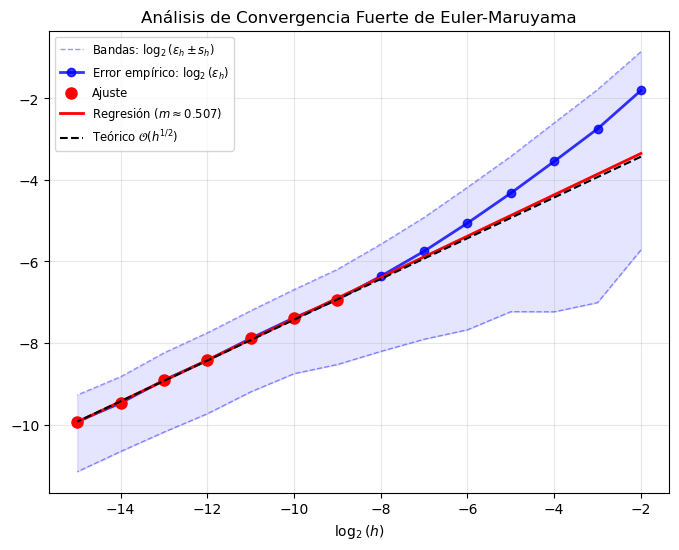

¡Hecho en 14.54 segundos!


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time

print("Calculando convergencia (2^2 a 2^15)...")
start_time = time.time()

# Parámetros (deben coincidir con la celda anterior)
X0, mu, sigma, T = 1.0, 1.0, 0.3, 1.0
M_sims = 1000 

N_vals = 2**np.arange(2, 16) 
h_vals = T / N_vals

# Cambiamos los nombres de las variables para que cuadren con la teoría
epsilon_h = np.zeros(len(N_vals)) # Esperanza empírica
s_h = np.zeros(len(N_vals))       # Desviación típica empírica

for idx, N in enumerate(N_vals):
    h = T / N
    t_g = np.linspace(0, T, N + 1)
    dW = np.sqrt(h) * np.random.normal(size=(M_sims, N))
    W = np.zeros((M_sims, N + 1))
    W[:, 1:] = np.cumsum(dW, axis=1) 
    
    X_ex = X0 * np.exp((mu - 0.5 * sigma**2) * t_g + sigma * W)
    X_em = np.zeros((M_sims, N + 1)); X_em[:, 0] = X0
    
    for i in range(N):
        X_em[:, i+1] = X_em[:, i] + mu * X_em[:, i] * h + sigma * X_em[:, i] * dW[:, i]
    
    # Error máximo temporal por trayectoria
    path_errors = np.max(np.abs(X_ex - X_em), axis=1)
    
    # 1. Esperanza empírica (\epsilon_h)
    epsilon_h[idx] = np.mean(path_errors)
    
    # 2. Desviación típica empírica (s_h)
    s_h[idx] = np.std(path_errors, ddof=1)

# Log-Log
log_h = np.log2(h_vals)
log_e = np.log2(epsilon_h)

# Bandas: log_2(\epsilon_h + s_h) y log_2(\epsilon_h - s_h)
log_e_plus = np.log2(epsilon_h + s_h)
log_e_minus = np.log2(np.maximum(epsilon_h - s_h, 1e-15)) 

# Regresión
num_puntos = 7
log_h_tail, log_e_tail = log_h[-num_puntos:], log_e[-num_puntos:]
pendiente, intercepto = np.polyfit(log_h_tail, log_e_tail, 1)

# Crear la figura
fig2, ax = plt.subplots(figsize=(8, 6))

# Área sombreada (Dispersión)
ax.fill_between(log_h, log_e_minus, log_e_plus, color='blue', alpha=0.1)

# Bandas punteadas con la notación de tu texto LaTeX
ax.plot(log_h, log_e_plus, 'b--', alpha=0.4, linewidth=1, label=r'Bandas: $\log_2(\epsilon_h \pm s_h)$')
ax.plot(log_h, log_e_minus, 'b--', alpha=0.4, linewidth=1)

# Error Empírico principal
ax.plot(log_h, log_e, 'bo-', alpha=0.8, linewidth=2, label=r'Error empírico: $\log_2(\epsilon_h)$')

# Ajustes y rectas teóricas
ax.plot(log_h_tail, log_e_tail, 'ro', markersize=8, label='Ajuste')
ax.plot(log_h, intercepto + pendiente * log_h, 'r-', linewidth=2, label=f'Regresión ($m \\approx {pendiente:.3f}$)')
ax.plot(log_h, (log_e[-1] - 0.5 * log_h[-1]) + 0.5 * log_h, 'k--', label=r'Teórico $\mathcal{O}(h^{1/2})$')

# Configuración de los ejes
ax.set_title('Análisis de Convergencia Fuerte de Euler-Maruyama')
ax.set_xlabel(r'$\log_2(h)$')

# Leyenda y rejilla
ax.legend(loc='best', fontsize='small')
ax.grid(True, alpha=0.3)

# GUARDAR ANTES DE MOSTRAR (con el nombre de archivo de tu documento)
fig2.savefig('ejemplo1_convergencia.pdf', bbox_inches='tight')
plt.show()

print(f"¡Hecho en {time.time() - start_time:.2f} segundos!")